# Kapitel 6 - Klustring

## Faktafrågor


1. klustring betyder när en oövervakad modell skapar olika grupper för datapunkter,beroande på hur dessa datapunkter tillhör varandra.

till exempel, ett företag som vill veta vad hur deras kunder ska grupperas beroande på hur de handlar osv. 

eller en markandsförings företag som gör klustring för att hitta olika grupper för att kunna anpassa sina reklam. 


2. k-means är oövervakad klustringsalgoritm som delar data i K grupper baserat på likhet. 

modellen presterar bra om storleken på de olika klustren är ungefär lika stora, klustren har liknande spridning och klustren har en sfärisk form. om detta är inte uppfyllt då finns det risk att en model presterar dåligt. och det kan man se i figur 6.4. 

## Resonemangfrågor



3. för att välja antal kluster för en k-means modell kan man göra antignen armbågskurva för att se hur många kluster som ger bra resultat. 

man kan välja k värde som ger bäst genomsnitlig silhouette score.  

man kan göra silhouette-diagram för att få mer detaljerad info om klustrer och k värde. 

4. jag hade valt 5 klustrer för att efter 5 så bidrar inte fler antal klustrer med så mycket fördel. det är inte exakt vetenskap att välja antal kluster man får helt enkelt välja det som ser bäst ut och testa sig fram. 

5. figuran visar silhouette-diagram för olika k-värde. i figuran kan man se tydligt att när man har för få antal kluster då är klustrerna ojämna vilket är inte önksevärt. när klustrer är för många då har vi vissa klustrer som inte ens når medel linjen vilket tyder på att dessa klustrer är svagare definerat än de andra. 

## Koduppgifter


uppgift_7

In [144]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [145]:
df = pd.read_csv("housing.csv")

In [146]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
silhouette_score:  0.33695012684165787
   median_income  latitude  longitude  Cluster
0         8.3252     37.88    -122.23        4
1         8.3014     37.86    -122.22        4
2         7.2574     37.85    -122.24        4
3         5.6431     37.85    -122.25        4
4         3.8462     37.85    -122.25        1


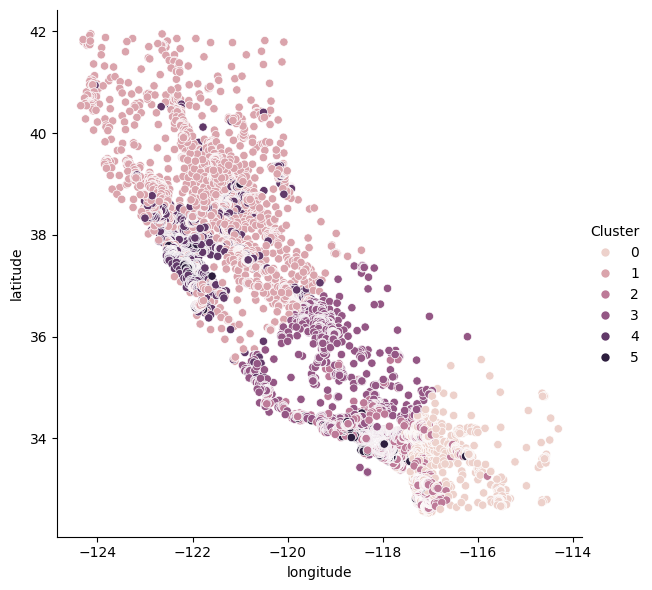

In [147]:
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

kmeans = KMeans(n_clusters=6)

labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print('silhouette_score: ', score)

X["Cluster"] = labels
print(X.head())

sns.relplot(
x="longitude", y="latitude", hue="Cluster", data=X, height=6,)


a) koden hämtar housing.csv datan och filtrer så att vi har bara medina_incom, latitude och logitude. 

sedan instansierar man kmeans där antal kluster är lika med 6. 

sedan gör man en fit_predict på X och sparar värdena i en ny kolumn "cluster". 

sedan plottar man alla klustrer där x och y axler är longitude och latitude. 

b) jag hade samalt följande information: dears yrke, lön, boandetyp, beteande analys, hur de föredrar att bli kontaktade och vad de värdesätter hos en säljare. 

c) ett företag kan göra olika typer av analys och med hjälp av det vi har tagit fram för att kunna göra anpassade marknadsföring. 

d) 

k:  2 , silhouette_score 0.628802672071265
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  Cluster  
0       322.0       126.0         8.3252            452600.0        1  
1      2401.0      1138.0         8.3014            358500.0        1  
2       496.0       177.0         7.2574            352100.0        1  
3       558.0       219.0         5.6431            341300.0        1  
4       565.0       259.0         3.8462            342200.0        1  


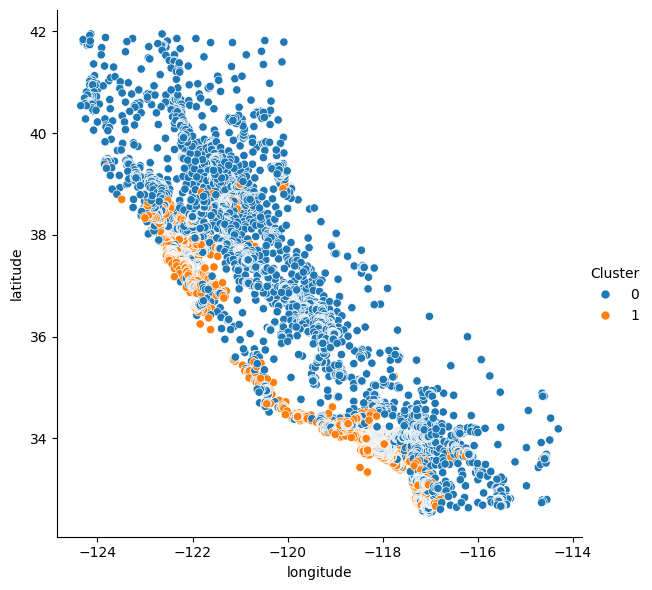

In [148]:
# X = df.loc[:, ["median_income", "latitude", "longitude"]]
X = df.drop(columns='ocean_proximity')
X = df.select_dtypes(include="number")
X = X.dropna()
best_k, best_score = 2, -1
for k in range(2,11):
    labels = KMeans(n_clusters = k, random_state=42, n_init=10).fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_k, best_score = k, score

model = KMeans(n_clusters=best_k, random_state=42, n_init=10 )
labels = model.fit_predict(X)
print('k: ', best_k, ', silhouette_score', best_score)

X["Cluster"] = labels
print(X.head())

sns.relplot(x="longitude", y="latitude", hue="Cluster", data=X, height=6,)

Text(0, 0.5, 'inertia')

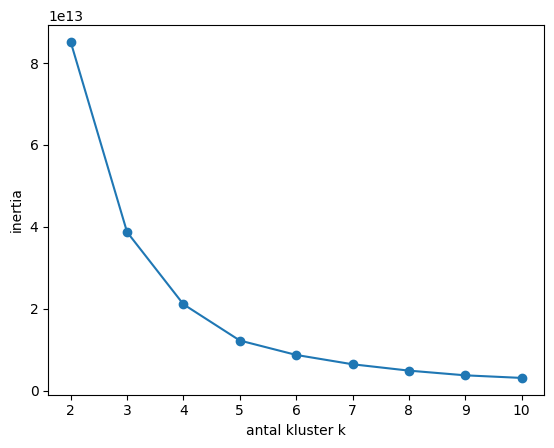

In [149]:
inertias = []

for k in range (2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)


plt.plot(range(2,11), inertias, marker = 'o')
plt.xlabel('antal kluster k')
plt.ylabel('inertia')

här ser vi att armbogsplotten och silhouette score visa olika saker, därför är silhouette score eller armbosplott inte den enda sannings källan utan man får avgöra vad som passar bäst i olika situationer. här armbogsplotten visar att k=6 är bäst antal klustrer medans silhouette tyder på att 2 kluster är bättre. rent matematisk 2 kluster är bättre för silhouettre beräkningar men i praktiken beroande på vad vi är ute efter kan 6 klustrer vara bättre.  

uppgift_8

In [150]:
from sklearn.decomposition import PCA


In [151]:
df = pd.read_excel('HR_Employee_Data.xlsx')

In [152]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [153]:
left = df['left']

X = df.drop(columns=['Emp_Id', 'left'])

X = pd.get_dummies(X, columns=['Department', 'salary'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [154]:
X.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False


In [155]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [156]:
df.groupby('cluster')['left'].agg(['mean', 'count'])

,mean,count
cluster,,
0,0.059561,319
1,0.187618,7430
2,0.297655,7250


In [157]:
df.groupby('cluster').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
cluster,,,,,,,,
0,0.656019,0.706019,3.752351,199.849530,4.166144,0.238245,0.059561,1.0
1,0.622999,0.715307,3.805114,201.065141,3.531090,0.144145,0.187618,0.0
2,0.600516,0.717360,3.803172,201.088000,3.435172,0.140966,0.297655,0.0


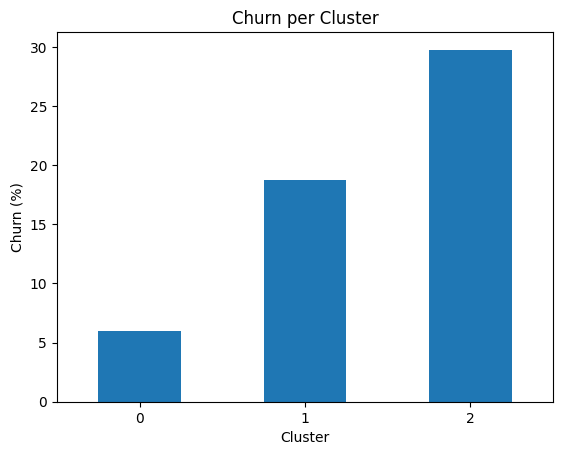

In [158]:
churn = df.groupby('cluster')['left'].mean() * 100

churn.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Churn (%)')
plt.title('Churn per Cluster')
plt.xticks(rotation=0)
plt.show()
    



ett företag kan använda sig av denna data för att förstå varför får de mycket churn på viss kluster och mindre churn på en annan och på så sätt göra ändringar i företaget för att behålla sina arbetstagare. 

uppgift_9

In [159]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [160]:
import kagglehub
import os

In [161]:
# Download latest version
path = kagglehub.dataset_download("thebumpkin/1980s-classic-hits-with-spotify-data")

print("Path to dataset files:", path)

print(os.listdir(path))

Path to dataset files: C:\Users\amir_\.cache\kagglehub\datasets\thebumpkin\1980s-classic-hits-with-spotify-data\versions\1
['1980sClassics.csv']


In [162]:
df = pd.read_csv(os.path.join(path, '1980sClassics.csv'))

In [163]:
df.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    str    
 1   Artist            998 non-null    str    
 2   Duration          998 non-null    str    
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dtypes: float

In [165]:
X = df.drop(columns=['Track','Artist','Duration'])

In [166]:
X_scaled = StandardScaler().fit_transform(X)

Text(0, 0.5, 'inertias')

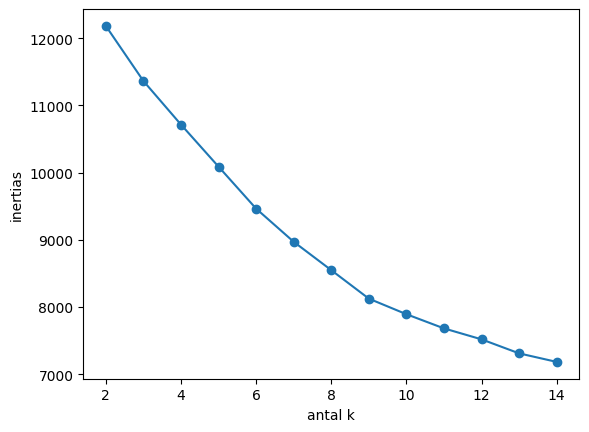

In [167]:
inertias = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2,15), inertias, marker='o')
plt.xlabel('antal k')
plt.ylabel('inertias')

In [168]:
best_k, best_score = 2, -1
for k in range(2,15):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score, best_k = score, k

model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = model.fit_predict(X_scaled)

print('best_k:', best_k, ', silhouette score:',best_score)


best_k: 2 , silhouette score: 0.1720729399215091
